# PREPROCESSING

In [1]:
# ===================== 1. KHAI BÁO & LOAD DỮ LIỆU =====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Cấu hình phong cách biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print('Đang xử lý dữ liệu từ data.xlsx ...')
df_raw = pd.read_excel('data.xlsx', sheet_name='Data')

# Làm sạch cột năm và đưa dữ liệu về long format
year_cols = [col for col in df_raw.columns if '[YR' in str(col)]
rename_dict = {col: int(str(col).split(' ')[0]) for col in year_cols}
df_raw = df_raw.rename(columns=rename_dict).replace('..', np.nan)

df_melted = pd.melt(
    df_raw,
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=list(rename_dict.values()),
    var_name='Year',
    value_name='Value'
)
df_melted['Value'] = pd.to_numeric(df_melted['Value'], errors='coerce')

# Tập quốc gia/nhóm cần phân tích
target_countries = [
    'Viet Nam', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines',
    'Brunei Darussalam', 'Cambodia', 'Lao PDR', 'Myanmar',
    'Timor-Leste', 'Singapore', 'High income', 'Middle income', 'Low income'
]

df_clean = df_melted[df_melted['Country Name'].isin(target_countries)].copy()

# Đặt tên indicator để dễ đọc/dễ vẽ biểu đồ
indicators = {
    'TX.VAL.TECH.MF.ZS': 'HighTech_Export',
    'GB.XPD.RSDV.GD.ZS': 'RnD',
    'IP.PAT.RESD': 'Patent_Resident',
    'IP.PAT.NRES': 'Patent_NonResident',
    'BX.KLT.DINV.WD.GD.ZS': 'FDI_Inflows',
    'HD_HCIP_OVRL_TO': 'HCI',
    'SL.EMP.WORK.ZS': 'Wage_Jobs',
    'SL.GDP.PCAP.EM.KD': 'Productivity',
    'SM.POP.NETM': 'Net_Migration',
    'BX.TRF.PWKR.DT.GD.ZS': 'Remittances',
    'CC.EST': 'WGI_CC',
    'GE.EST': 'WGI_GE',
    'VA.EST': 'WGI_VA',
    'RQ.EST': 'WGI_RQ',
    'RL.EST': 'WGI_RL',
    'PV.EST': 'WGI_PV',
    'NV.MNF.TECH.ZS.UN': 'Tech_ValueAdded'
}

# Tạo bảng đa biến (super matrix)
df_multi = (
    df_clean
    .pivot_table(index=['Country Name', 'Year'], columns='Series Code', values='Value')
    .reset_index()
    .rename(columns=indicators)
)

# Tạo lại dict `data` để dùng cho Heatmap
def build_indicator_frame(df_input, indicator_name):
    if indicator_name not in df_input.columns: return None
    return (
        df_input[['Country Name', 'Year', indicator_name]]
        .pivot(index='Year', columns='Country Name', values=indicator_name)
        .reset_index()
        .sort_values('Year')
    )

data = {code: build_indicator_frame(df_multi, name) for code, name in indicators.items()}

print(f"Xử lý xong! Kích thước df_multi: {df_multi.shape}")

Đang xử lý dữ liệu từ data.xlsx ...
Xử lý xong! Kích thước df_multi: (350, 20)


In [2]:
# ===================== CHECK MISSING VALUES =====================
print('===== KIEM TRA MISSING TREN df_multi =====')

# 1) Tong quan
n_rows, n_cols = df_multi.shape
total_missing = int(df_multi.isna().sum().sum())
print(f'So dong: {n_rows}, so cot: {n_cols}')
print(f'Tong so gia tri missing: {total_missing}')

# 2) Missing theo cot
missing_by_col = df_multi.isna().sum().sort_values(ascending=False)
missing_by_col = missing_by_col[missing_by_col > 0]

if missing_by_col.empty:
    print('Khong co cot nao bi missing.')
else:
    print('\nSo luong missing theo cot:')
    print(missing_by_col)

# 3) Missing o dong nao + cot nao
miss_locs = (
    df_multi.isna()
    .stack()
    .loc[lambda s: s]
    .rename('is_missing')
    .reset_index()
)

# Dat ten row index on dinh
if 'level_0' in miss_locs.columns:
    miss_locs = miss_locs.rename(columns={'level_0': 'row_idx'})

# Xac dinh cot chua ten bien bi missing (co the la level_1 hoac ten cot goc, vd: Series Code)
meta_like = {'row_idx', 'Country Name', 'Year', 'is_missing'}
missing_col_candidates = [c for c in miss_locs.columns if c not in meta_like]

if missing_col_candidates:
    miss_locs = miss_locs.rename(columns={missing_col_candidates[0]: 'missing_column'})
else:
    miss_locs['missing_column'] = np.nan

# Loai bo cot bool trung gian
if 'is_missing' in miss_locs.columns:
    miss_locs = miss_locs.drop(columns=['is_missing'])

if miss_locs.empty:
    print('\nKhong co missing o cap do o (dong, cot).')
else:
    miss_locs = miss_locs.merge(
        df_multi[['Country Name', 'Year']].reset_index().rename(columns={'index': 'row_idx'}),
        on='row_idx',
        how='left'
    )

    # Chi giu cac cot can xem, tranh KeyError neu thieu cot bat ky
    keep_cols = [c for c in ['row_idx', 'Country Name', 'Year', 'missing_column'] if c in miss_locs.columns]
    miss_locs = miss_locs[keep_cols]

    print(f"\nTong so diem missing (dong, cot): {len(miss_locs)}")
    print('Top 30 diem missing dau tien:')
    print(miss_locs.head(30))

# 4) Dong nao missing nhieu nhat
row_missing_count = df_multi.isna().sum(axis=1)
rows_with_missing = row_missing_count[row_missing_count > 0].sort_values(ascending=False)

if rows_with_missing.empty:
    print('\nKhong co dong nao bi missing.')
else:
    top_rows = rows_with_missing.head(10).index
    summary_rows = df_multi.loc[top_rows, ['Country Name', 'Year']].copy()
    summary_rows['missing_count'] = row_missing_count.loc[top_rows].values

    print('\nTop 10 dong missing nhieu nhat:')
    print(summary_rows)


===== KIEM TRA MISSING TREN df_multi =====
So dong: 350, so cot: 20
Tong so gia tri missing: 1869

So luong missing theo cot:
Series Code
HCI                   316
RnD                   214
Patent_Resident       163
HighTech_Export       148
Patent_NonResident    138
Tech_ValueAdded       130
WGI_RQ                108
WGI_RL                108
WGI_VA                108
WGI_PV                108
WGI_GE                108
WGI_CC                108
Remittances            67
FDI_Inflows            17
NY.GDP.PCAP.KD         14
Productivity           14
dtype: int64

Tong so diem missing (dong, cot): 1869
Top 30 diem missing dau tien:
    row_idx       Country Name  Year   missing_column
0         0  Brunei Darussalam  2001      Remittances
1         0  Brunei Darussalam  2001           WGI_CC
2         0  Brunei Darussalam  2001              RnD
3         0  Brunei Darussalam  2001           WGI_GE
4         0  Brunei Darussalam  2001              HCI
5         0  Brunei Darussalam  2001  P

===== VẼ BIỂU ĐỒ MISSING DATA CHO TOÀN BỘ INDICATORS =====


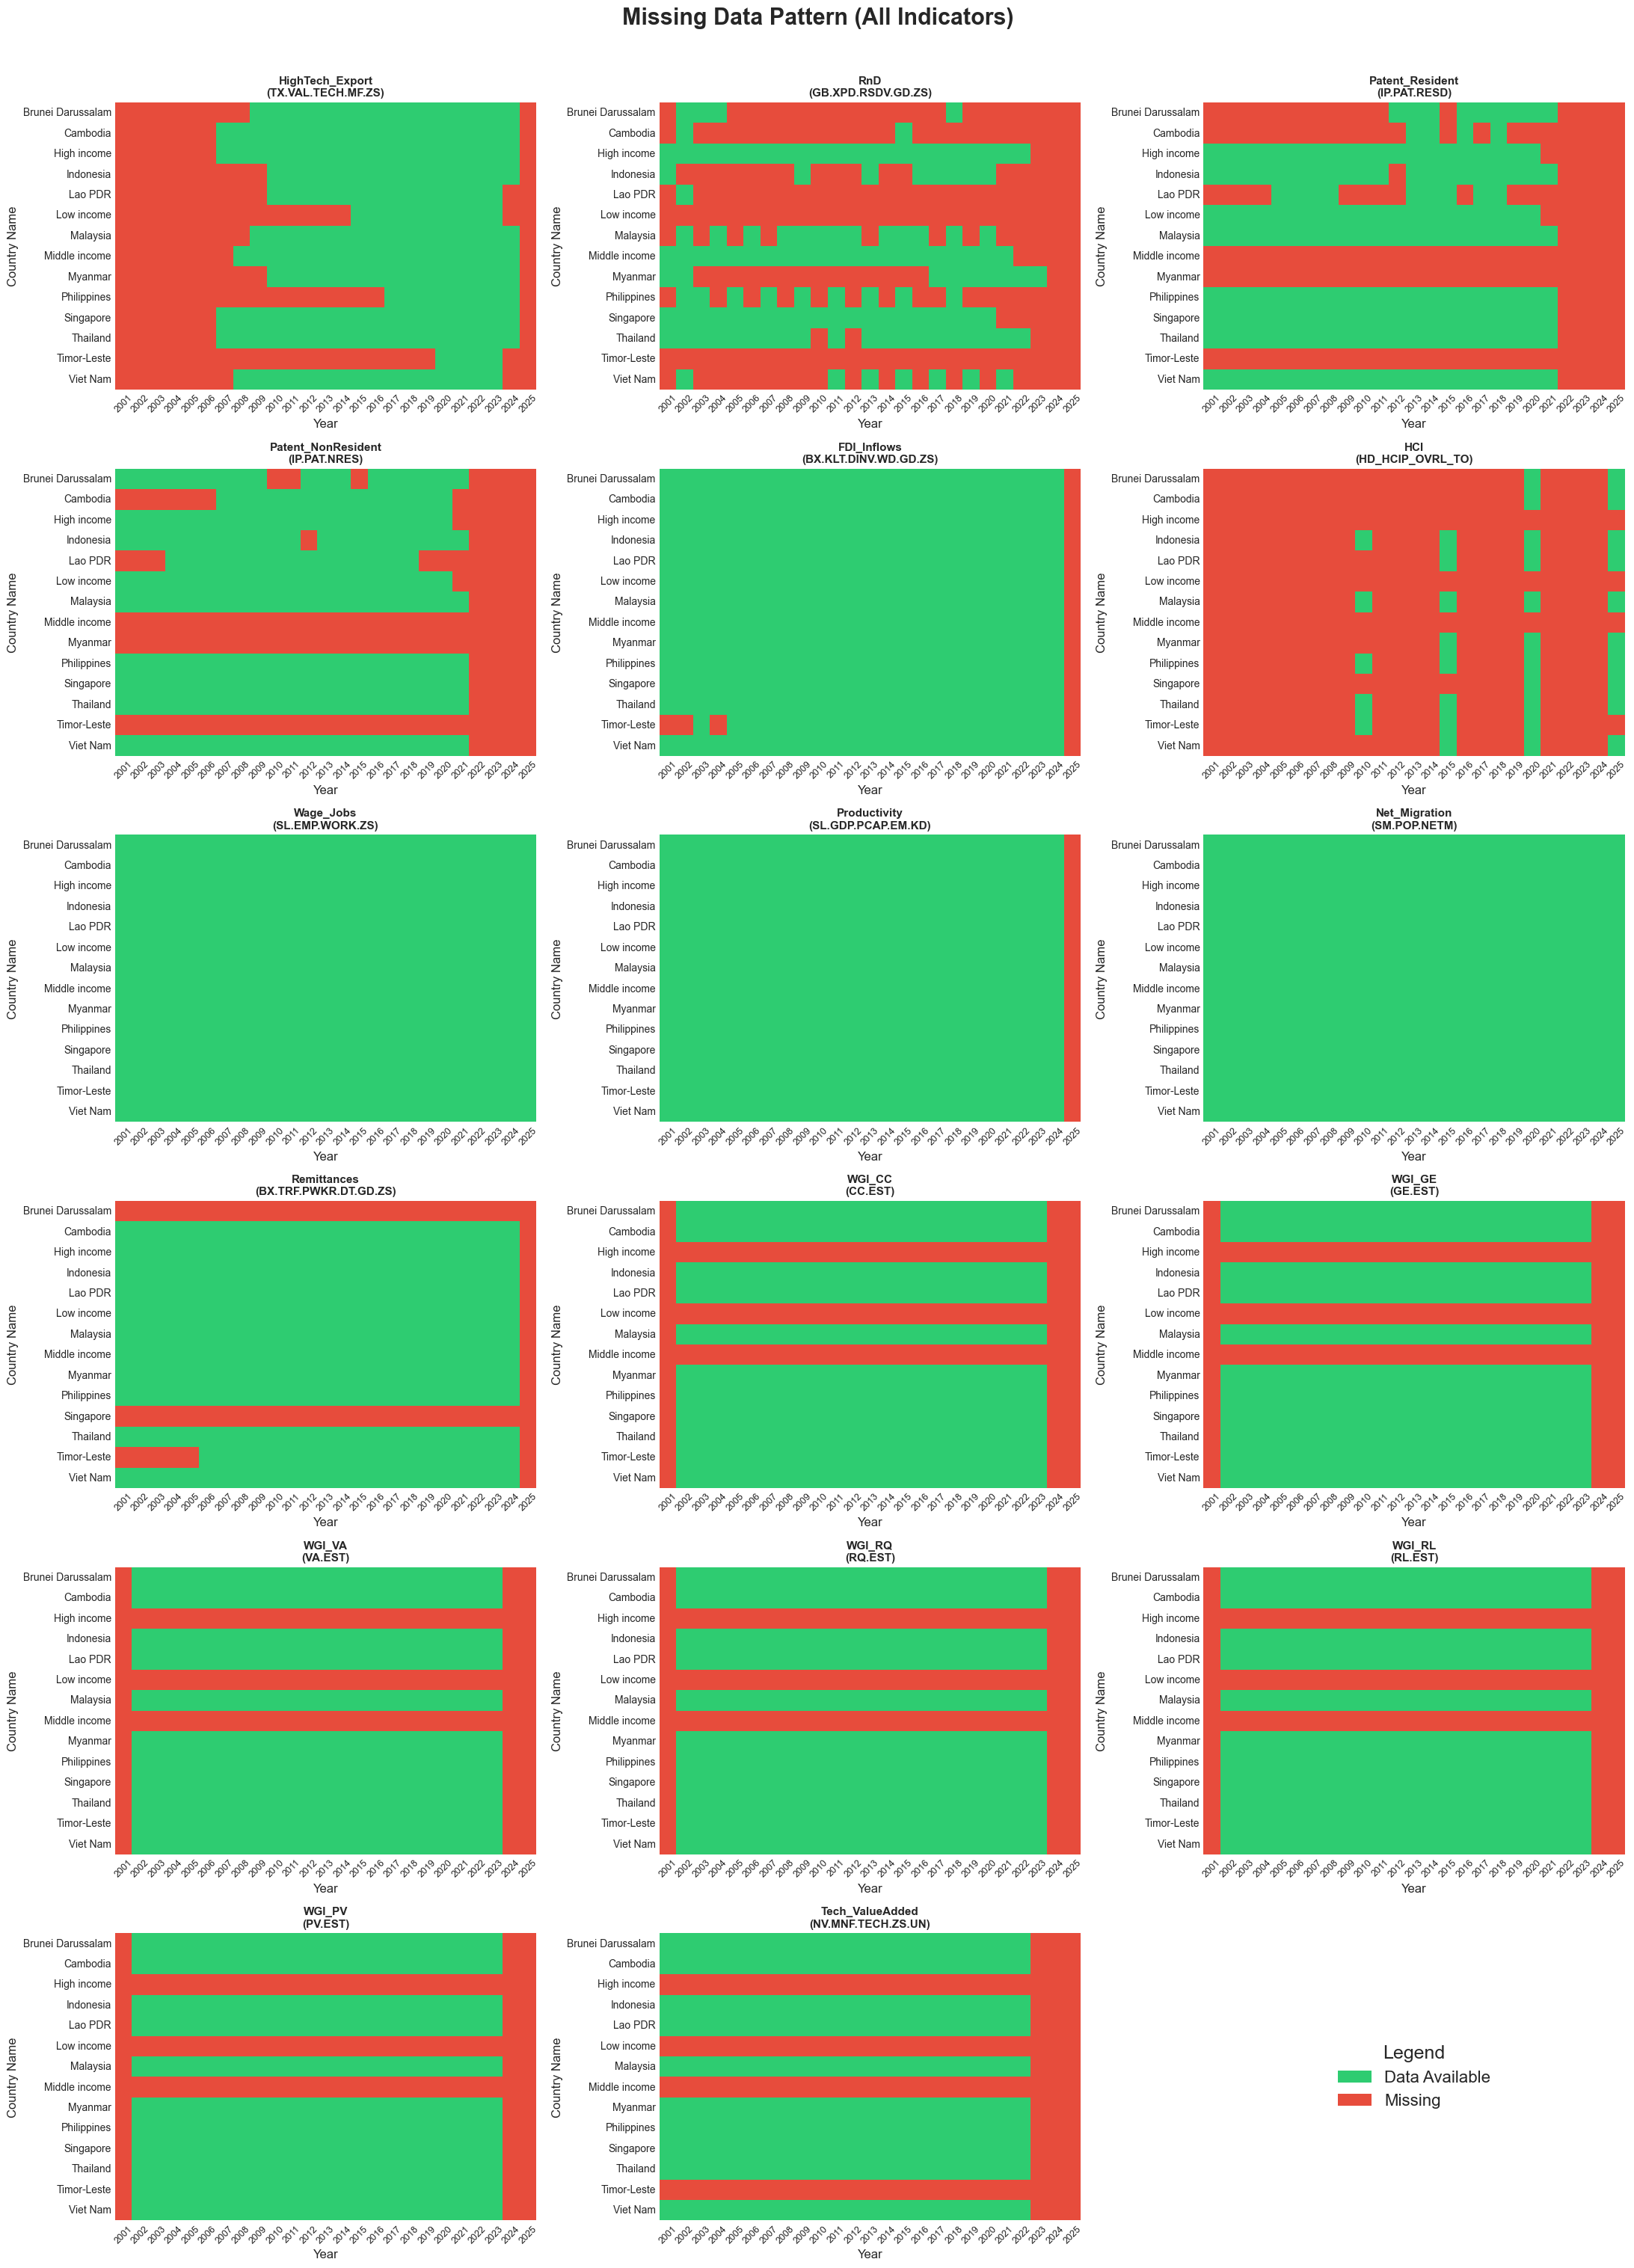

Đã lưu biểu đồ: missing_data_pattern_all.pdf


In [3]:
# ===================== MISSING DATA HEATMAP (ALL INDICATORS) =====================
print('===== VẼ BIỂU ĐỒ MISSING DATA CHO TOÀN BỘ INDICATORS =====')

# Lấy toàn bộ danh sách codes
plot_codes = list(indicators.keys())

# Cấu hình layout 6 rows x 3 columns = 18 ô (17 indicators + 1 legend)
fig, axes = plt.subplots(6, 3, figsize=(22, 30))
axes = axes.flatten()

for idx, code in enumerate(plot_codes):
    ax = axes[idx]
    if code in data:
        # Lấy dữ liệu thô (chưa fill missing) để xem pattern thực tế
        df_plot = data[code].copy().set_index('Year')
        
        sns.heatmap(
            df_plot.isna().T,
            cbar=False,
            ax=ax,
            yticklabels=True,
            cmap=['#2ecc71', '#e74c3c']  # Green=data, Red=missing
        )
        ax.set_title(f"{indicators[code]}\n({code})", fontsize=11, weight='bold')
        ax.set_xlabel('Year')
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.tick_params(axis='y', labelsize=10)
    else:
        # Trường hợp biến bị lỗi/không lấy được data
        ax.axis('off')
        ax.text(0.5, 0.5, f"No data for:\n{indicators[code]}", 
                ha='center', va='center', fontsize=12, color='gray')

# Ô cuối cùng (index 17) dành cho Legend
ax_legend = axes[17]
ax_legend.axis('off')
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Data Available'),
    Patch(facecolor='#e74c3c', label='Missing')
]
ax_legend.legend(handles=legend_elements, loc='center', fontsize=16, 
                 title='Legend', title_fontsize=18)

plt.suptitle('Missing Data Pattern (All Indicators)', fontsize=22, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('missing_data_pattern_all.pdf', dpi=300, bbox_inches='tight')
plt.show()

print('Đã lưu biểu đồ: missing_data_pattern_all.pdf')

# QUESTIONS

**Research Question:** To what extent does Vietnam's high-tech export-driven growth model reflect endogenous innovation capacity, as opposed to being primarily dependent on foreign direct investment (FDI)?

**Tiếng Việt:**
Mô hình tăng trưởng dựa vào xuất khẩu công nghệ cao của Việt Nam phản ánh năng lực đổi mới nội sinh đến mức độ nào, so với việc chủ yếu phụ thuộc vào đầu tư trực tiếp nước ngoài (FDI)?

Để trả lời câu hỏi nghiên cứu trên, dữ liệu được trực quan hóa qua hai biểu đồ chính với các biến số được quy ước như sau:

**A. Biểu đồ phân tán (Scatter Plot) - Mối quan hệ giữa Xuất khẩu công nghệ cao và Năng lực R&D:**
* **Trục hoành (X-axis):** Cường độ R&D (`RnD` - % GDP) - Đại diện cho nỗ lực đầu tư vào nghiên cứu và phát triển.
* **Trục tung (Y-axis):** Tỷ trọng xuất khẩu công nghệ cao (`HighTech_Export` - % trong tổng xuất khẩu ngành chế tạo) - Đại diện cho đầu ra thương mại.
* **Kích thước bong bóng (Bubble Size):** Quy mô dòng vốn FDI (`FDI_Inflows`) - Đại diện cho mức độ can thiệp/đóng góp của doanh nghiệp nước ngoài.
* **Màu sắc (Color):** Màu đỏ sẫm (Highlight) được dùng để làm nổi bật vị thế của Việt Nam khi đối chiếu với mức trung bình của các nhóm quốc gia theo mức thu nhập (Thấp, Trung bình, Cao).

**B. Biểu đồ thanh ngang (Bar Chart) - Cấu trúc sở hữu bằng sáng chế:**
* **Thanh màu đỏ (`NonRes_Pct`):** Tỷ trọng bằng sáng chế thuộc sở hữu nước ngoài (Sự phụ thuộc công nghệ).
* **Thanh màu xanh (`Res_Pct`):** Tỷ trọng bằng sáng chế thuộc sở hữu nội địa (Năng lực làm chủ và đổi mới nội sinh).

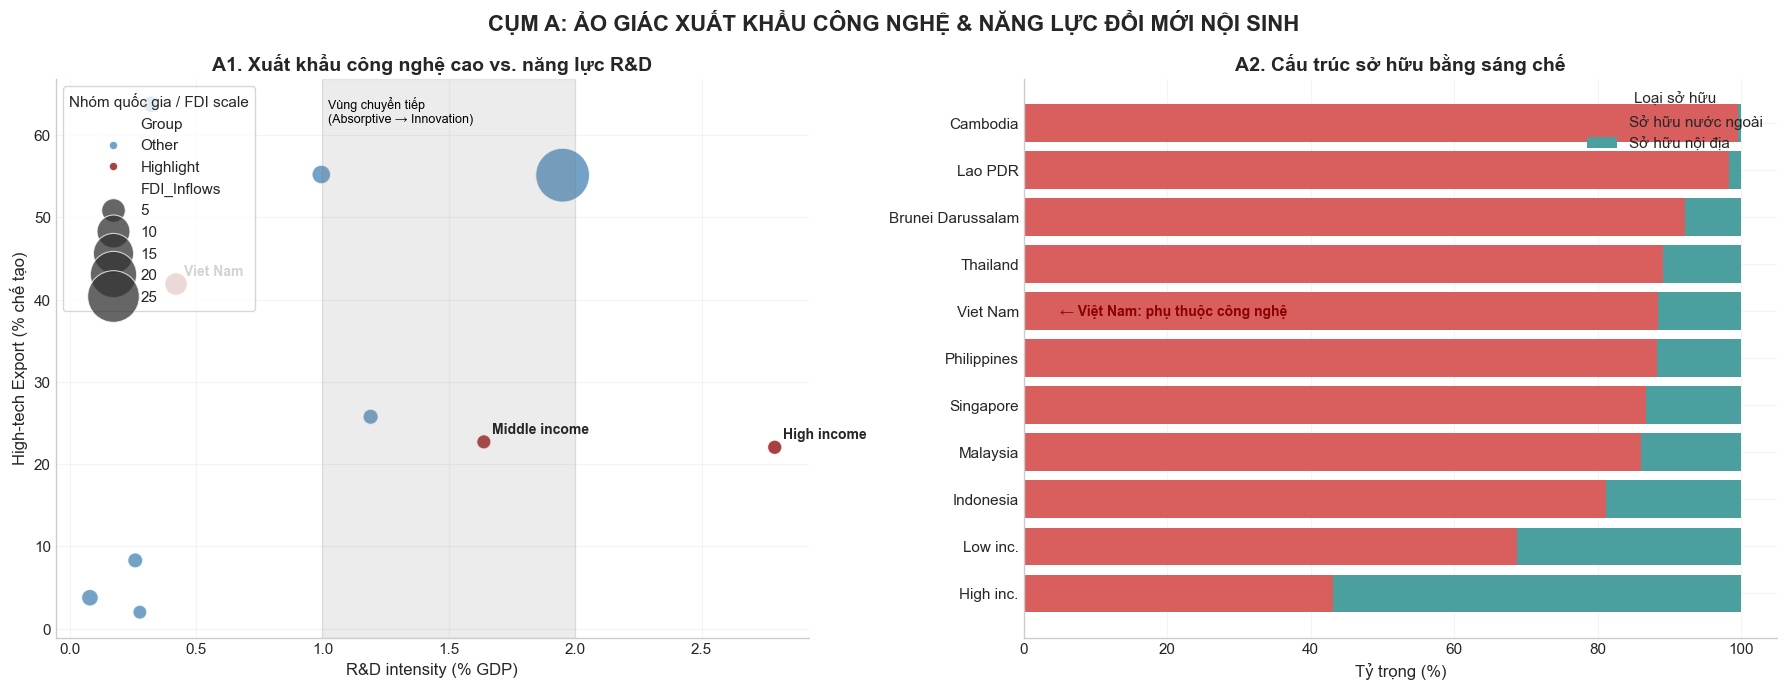

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('CỤM A: ẢO GIÁC XUẤT KHẨU CÔNG NGHỆ & NĂNG LỰC ĐỔI MỚI NỘI SINH',
             weight='bold', fontsize=16)

# ===================== A1: SCATTER =====================
df_a1 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['RnD', 'HighTech_Export', 'FDI_Inflows']]
    .mean()
    .reset_index()
    .dropna()
)

highlight = ['Viet Nam', 'Low income', 'High income', 'Middle income']

# Tạo cột phân loại màu
df_a1['Group'] = df_a1['Country Name'].apply(
    lambda x: 'Highlight' if x in highlight else 'Other'
)

palette = {'Highlight': 'darkred', 'Other': 'steelblue'}

scatter = sns.scatterplot(
    data=df_a1,
    x='RnD',
    y='HighTech_Export',
    size='FDI_Inflows',
    hue='Group',
    palette=palette,
    sizes=(100, 1500),
    alpha=0.75,
    ax=axes[0]
)

# Annotate highlight
for _, row in df_a1.iterrows():
    if row['Country Name'] in highlight:
        axes[0].annotate(
            row['Country Name'],
            (row['RnD'], row['HighTech_Export']),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            weight='bold'
        )

# ===== VÙNG CHUYỂN TIẾP R&D (thay vì "ngưỡng cứng") =====
axes[0].axvspan(1.0, 2.0, color='grey', alpha=0.15)

axes[0].text(
    1.02,
    axes[0].get_ylim()[1] * 0.92,
    'Vùng chuyển tiếp\n(Absorptive → Innovation)',
    fontsize=9,
    color='black'
)

axes[0].set_title('A1. Xuất khẩu công nghệ cao vs. năng lực R&D', weight='bold')
axes[0].set_xlabel('R&D intensity (% GDP)')
axes[0].set_ylabel('High-tech Export (% chế tạo)')


# Fix legend cho scatter
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles=handles,
    labels=labels,
    title='Nhóm quốc gia / FDI scale',
    loc='upper left',
    frameon=True
)


# ===================== A2: BAR =====================
df_a2 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['Patent_Resident', 'Patent_NonResident']]
    .mean()
    .reset_index()
    .dropna()
)

df_a2['Total'] = df_a2['Patent_Resident'] + df_a2['Patent_NonResident']
df_a2['Res_Pct'] = df_a2['Patent_Resident'] / df_a2['Total'] * 100
df_a2['NonRes_Pct'] = df_a2['Patent_NonResident'] / df_a2['Total'] * 100

df_a2 = df_a2.sort_values('NonRes_Pct')

df_a2['Short_Name'] = df_a2['Country Name'].str.replace('income', 'inc.', regex=False)

# Bar chart
axes[1].barh(
    df_a2['Short_Name'],
    df_a2['NonRes_Pct'],
    color='#d95f5f',
    label='Sở hữu nước ngoài'
)
axes[1].barh(
    df_a2['Short_Name'],
    df_a2['Res_Pct'],
    left=df_a2['NonRes_Pct'],
    color='#4c9f9f',
    label='Sở hữu nội địa'
)

axes[1].set_title('A2. Cấu trúc sở hữu bằng sáng chế', weight='bold')
axes[1].set_xlabel('Tỷ trọng (%)')

# Highlight Việt Nam
for i, name in enumerate(df_a2['Country Name']):
    if name == 'Viet Nam':
        axes[1].text(
            5, i,
            '← Việt Nam: phụ thuộc công nghệ',
            va='center',
            fontsize=10,
            weight='bold',
            color='darkred'
        )

axes[1].legend(title='Loại sở hữu', loc='upper right')


# ===================== FINAL TOUCH =====================
for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

- Việt Nam có tỷ trọng xuất khẩu công nghệ cực kỳ cao (vượt xa cả Middle Income và High Income), tuy nhiên về cường độ R&D lại nằm ở mức thấp nhất và cách rất xa vùng chuyển tiếp. Điều này cho thấy sự chênh lệch khổng lồ giữa đầu vào và đầu ra, chúng ta đang xuất khẩu những thứ mà chúng ta chưa hề tạo ra.
- Kích thước bong bóng thể hiện quy mô FDI Inflows, nó là vai trò là "công xưởng gia công, lắp ráp" (hưởng phần giá trị gia tăng thấp nhất trong chuỗi cung ứng), chứ không phải là quốc gia làm chủ công nghệ
- So với nhóm nước có thu nhập cao (tỷ lệ sở hữu nội địa chiếm hơn 50%), hay thậm chí là nhóm nước có thu nhập thấp (Low inc. - sở hữu nội địa chiếm khoảng 30%), Việt Nam đang ở trạng thái lệ thuộc hoàn toàn về công nghệ. Không nắm giữ bằng sáng chế đồng nghĩa với việc nền kinh tế không có "năng lực đổi mới nội sinh". Nếu dòng vốn FDI rút đi hoặc dịch chuyển sang quốc gia khác, "ảo giác" xuất khẩu này sẽ ngay lập tức sụp đổ.

 
Is Vietnam effectively leveraging its human capital, or is it experiencing resource underutilization due to structural constraints in the labor market?

Việt Nam có đang tận dụng hiệu quả nguồn nhân lực của mình hay đang gặp phải tình trạng sử dụng nguồn lực chưa hiệu quả do những hạn chế về cấu trúc trong thị trường lao động?


Cụm B sử dụng hai biểu đồ để chứng minh "nghịch lý vốn con người", với các biến số cụ thể:

**B1. Biểu đồ phân tán (Scatter Plot) - Nghịch lý Đào tạo và Việc làm:**
* **Trục hoành (X-axis):** Chỉ số Vốn con người (`HCI`) - Đại diện cho chất lượng nguồn lao động, trình độ giáo dục và y tế.
* **Trục tung (Y-axis):** Tỷ lệ việc làm có lương ổn định (`Wage_Jobs`) - Đại diện cho khả năng cung cấp việc làm chất lượng cao, chính thức của nền kinh tế.
* **Đường nét đứt (Dashed lines):** Mức trung bình của tập dữ liệu. Điểm giao cắt chia biểu đồ thành 4 góc phần tư.

**B2. Biểu đồ cột (Bar Chart) - Hệ quả Di cư và Kiều hối:**
* **Thanh màu đỏ (`Net_Migration_Scaled`):** Tỷ lệ di cư ròng. Giá trị âm thể hiện số người rời khỏi đất nước nhiều hơn số người nhập cư (chảy máu lao động/chất xám).
* **Thanh màu xanh (`Remittances`):** Kiều hối tính theo % GDP - Đại diện cho nguồn tiền từ lao động xuất khẩu gửi về nước.

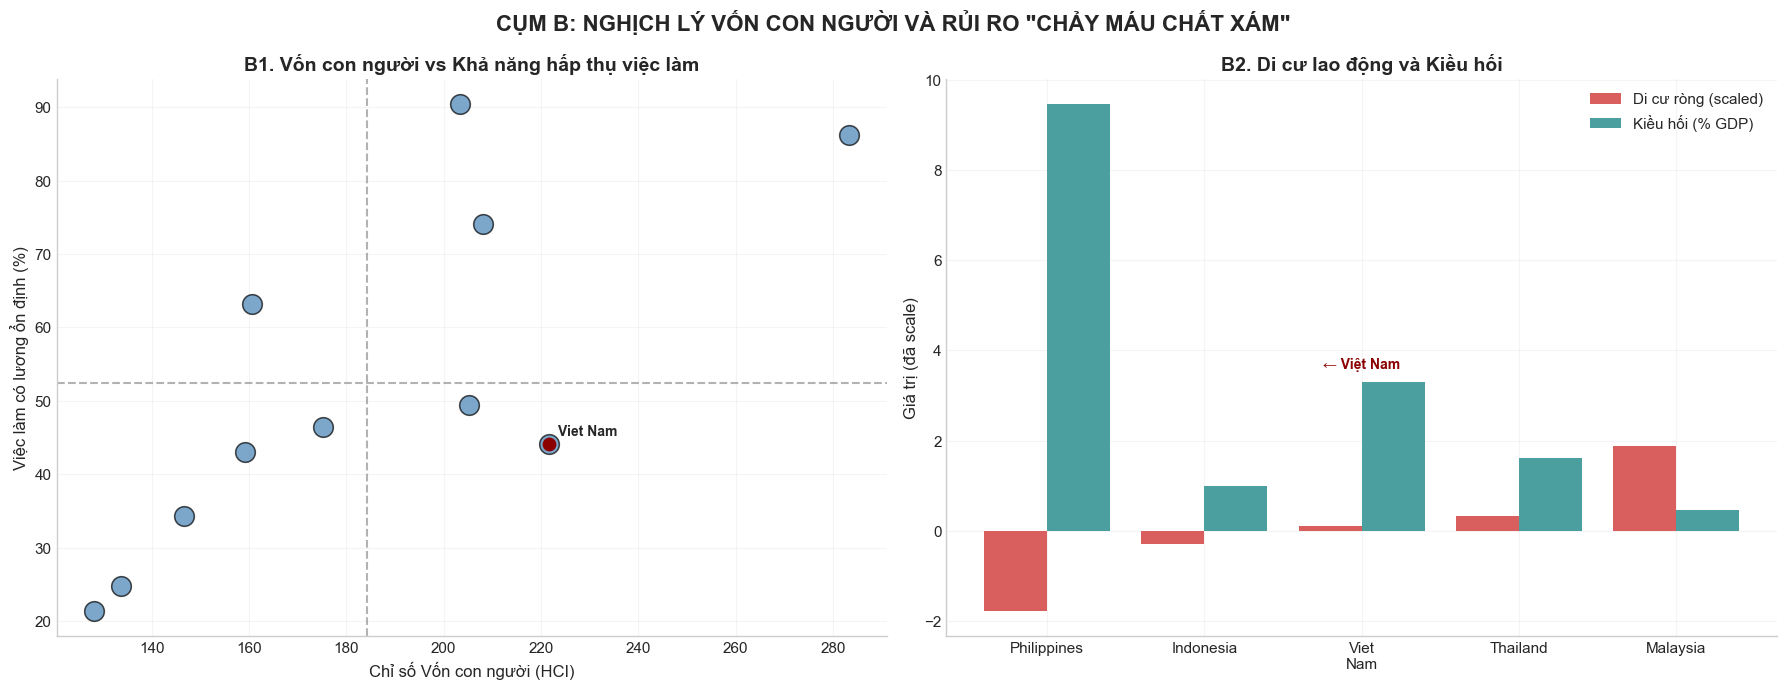

In [5]:
# ===================== PLOT: CLUSTER B =====================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('CỤM B: NGHỊCH LÝ VỐN CON NGƯỜI VÀ RỦI RO "CHẢY MÁU CHẤT XÁM"',
             weight='bold', fontsize=16)

# ===================== B1: SCATTER =====================
df_b1 = (
    df_multi[df_multi['Year'] == 2020]
    .dropna(subset=['HCI', 'Wage_Jobs'])
)

sns.scatterplot(
    data=df_b1,
    x='HCI',
    y='Wage_Jobs',
    color='steelblue',
    s=200,
    alpha=0.7,
    edgecolor='black',
    legend=False,
    ax=axes[0]
)

# Highlight giống style A
highlight = ['Viet Nam', 'Low income', 'High income', 'Middle income']

for _, row in df_b1.iterrows():
    if row['Country Name'] in highlight:
        axes[0].scatter(row['HCI'], row['Wage_Jobs'],
                        color='darkred', s=80, zorder=3)
        axes[0].annotate(
            row['Country Name'],
            (row['HCI'], row['Wage_Jobs']),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=10,
            weight='bold'
        )

# Mean lines (giữ nhưng clean)
axes[0].axvline(df_b1['HCI'].mean(), color='gray', linestyle='--', alpha=0.6)
axes[0].axhline(df_b1['Wage_Jobs'].mean(), color='gray', linestyle='--', alpha=0.6)

axes[0].set_title('B1. Vốn con người vs Khả năng hấp thụ việc làm', weight='bold')
axes[0].set_xlabel('Chỉ số Vốn con người (HCI)')
axes[0].set_ylabel('Việc làm có lương ổn định (%)')


# ===================== B2: BAR (FIX CLEAN) =====================
df_b2 = (
    df_multi[df_multi['Year'] >= 2015]
    .groupby('Country Name')[['Net_Migration', 'Remittances']]
    .mean()
    .reset_index()
    .dropna()
)

focus_mig = ['Philippines', 'Viet Nam', 'Indonesia', 'Thailand', 'Malaysia', 'Singapore']
df_b2 = df_b2[df_b2['Country Name'].isin(focus_mig)]

# Scale nhẹ (tránh bị dồn)
df_b2['Net_Migration_Scaled'] = df_b2['Net_Migration'] / 100000

# Sort cho đẹp
df_b2 = df_b2.sort_values('Net_Migration_Scaled')

# Rút gọn tên
df_b2['Short_Name'] = df_b2['Country Name'].str.replace(' ', '\n')

x = np.arange(len(df_b2))

axes[1].bar(
    x - 0.2,
    df_b2['Net_Migration_Scaled'],
    width=0.4,
    color='#d95f5f',
    label='Di cư ròng (scaled)'
)

axes[1].bar(
    x + 0.2,
    df_b2['Remittances'],
    width=0.4,
    color='#4c9f9f',
    label='Kiều hối (% GDP)'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(df_b2['Short_Name'])

axes[1].set_title('B2. Di cư lao động và Kiều hối', weight='bold')
axes[1].set_ylabel('Giá trị (đã scale)')

# Highlight Việt Nam
for i, name in enumerate(df_b2['Country Name']):
    if name == 'Viet Nam':
        axes[1].text(
            i,
            df_b2.iloc[i]['Remittances'] + 0.3,
            '← Việt Nam',
            ha='center',
            fontsize=10,
            weight='bold',
            color='darkred'
        )

axes[1].legend(loc='upper right')


# ===================== FINAL TOUCH =====================
for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

- Chúng ta đang có độ vênh nghiêm trọng giữa Giáo dục và Nền kinh tế. Hệ thống giáo dục tạo ra nguồn nhân lực có chất lượng khá tốt, nhưng nền kinh tế nội địa lại không có đủ khả năng hấp thụ. Điều này rất khớp với giả thuyết ở Cụm A: một nền kinh tế chủ yếu làm gia công, lắp ráp thì không cần (và không có) nhiều vị trí việc làm chất lượng cao để cung cấp cho người lao động.
- Nguồn kiều hối khổng lồ đổ về chính là minh chứng rõ ràng nhất cho việc nền kinh tế đang phải giải quyết bài toán thất nghiệp/việc làm chất lượng thấp bằng con đường xuất khẩu lao động và chuyên gia.
- Kiều hối là một nguồn lực ngoại tệ tuyệt vời giúp ổn định an sinh xã hội và kinh tế vĩ mô trong ngắn hạn. Tuy nhiên, nếu coi đây là một thành tích để tự hào thì đó là một rủi ro cực lớn. Nó cho thấy chúng ta đang không thể giữ chân những người giỏi nhất. Đất nước đang "trợ cấp" trí tuệ và sức trẻ của mình để xây dựng nền kinh tế cho quốc gia khác, làm triệt tiêu cơ hội xây dựng năng lực đổi mới sáng tạo nội sinh.

**Research Question:** To what extent do current institutional constraints limit Vietnam's transition toward a knowledge-based growth model, and what are their broader impacts?

**Câu hỏi nghiên cứu:** Những hạn chế về thể chế hiện tại đang cản trở quá trình chuyển đổi của Việt Nam sang mô hình tăng trưởng dựa trên tri thức đến mức độ nào, và những tác động rộng hơn của chúng là gì?

Cụm C sử dụng hai biểu đồ để đánh giá "hạ tầng phần mềm" của nền kinh tế (thể chế), với các biến số:

**C1. Biểu đồ Radar - Đường ray thể chế (WGI 2021):**
* Thể hiện 6 chỉ số quản trị toàn cầu (Worldwide Governance Indicators - WGI). Giá trị nằm trong lõi (âm) thể hiện chất lượng thể chế yếu; mở rộng ra viền ngoài (dương) là thể chế mạnh.
* **Đường màu đỏ đậm:** Điểm số thực tế của Việt Nam đối chiếu trên 6 trục (Tham nhũng, Hiệu quả Chính phủ, Tiếng nói, Pháp lý, Pháp quyền, Ổn định). Các đường màu xám là nhóm đối sánh (Singapore, Malaysia, High Income).

**C2. Biểu đồ phân tán - Pháp quyền và năng lực công nghệ lõi:**
* **Trục hoành (X-axis):** Chỉ số Pháp quyền (`WGI_RL` từ -2.5 đến 2.5) - Đại diện cho tính nghiêm minh, bảo vệ quyền tài sản và hợp đồng.
* **Trục tung (Y-axis):** Giá trị gia tăng công nghệ (`Tech_ValueAdded` - %) - Đại diện cho năng lực tạo ra lõi công nghệ thực chất.
* **Đường đứt nét màu đỏ:** Ngưỡng 0 của Pháp quyền, ranh giới giữa hệ thống pháp lý yếu kém (trái) và ổn định (phải).

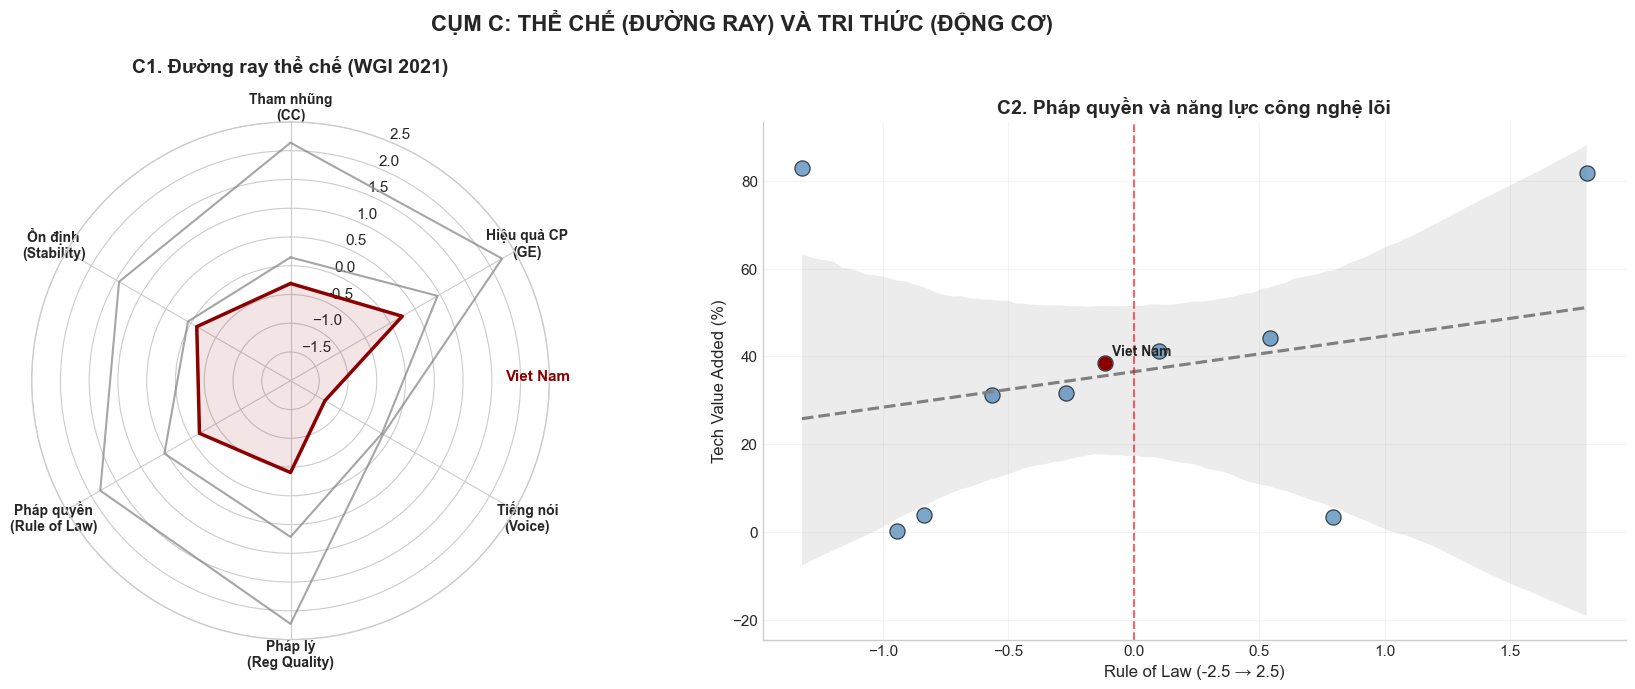

In [6]:

fig = plt.figure(figsize=(18, 7))
fig.suptitle('CỤM C: THỂ CHẾ (ĐƯỜNG RAY) VÀ TRI THỨC (ĐỘNG CƠ)',
             weight='bold', fontsize=16)

# ===================== C1: RADAR =====================
ax_radar = fig.add_subplot(1, 2, 1, polar=True)

wgi_cols = ['WGI_CC', 'WGI_GE', 'WGI_VA', 'WGI_RQ', 'WGI_RL', 'WGI_PV']
wgi_labels = [
    'Tham nhũng\n(CC)', 'Hiệu quả CP\n(GE)', 'Tiếng nói\n(Voice)',
    'Pháp lý\n(Reg Quality)', 'Pháp quyền\n(Rule of Law)', 'Ổn định\n(Stability)'
]

df_c1 = df_multi[df_multi['Year'] == 2021].dropna(subset=wgi_cols)

# chỉ focus như các cluster trước
focus_rad = ['Viet Nam', 'Singapore', 'Malaysia', 'High income']

angles = np.linspace(0, 2*np.pi, len(wgi_cols), endpoint=False).tolist()
angles += angles[:1]

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(wgi_labels, fontsize=10, weight='bold')
ax_radar.set_ylim(-2, 2.5)

for c in focus_rad:
    if c in df_c1['Country Name'].values:
        vals = df_c1[df_c1['Country Name'] == c][wgi_cols].values.flatten().tolist()
        vals += vals[:1]

        # highlight Viet Nam giống style trước
        if c == 'Viet Nam':
            ax_radar.plot(angles, vals, color='darkred', linewidth=2.5)
            ax_radar.fill(angles, vals, color='darkred', alpha=0.1)
        else:
            ax_radar.plot(angles, vals, color='gray', linewidth=1.5, alpha=0.7)

ax_radar.set_title('C1. Đường ray thể chế (WGI 2021)', weight='bold', y=1.08)

# bỏ legend để sạch (giống A, B)
ax_radar.text(np.pi/2, 2.3, 'Viet Nam', color='darkred', ha='center', weight='bold')


# ===================== C2: SCATTER =====================
ax_scatter = fig.add_subplot(1, 2, 2)

df_c2 = (
    df_multi[df_multi['Year'] >= 2018]
    .groupby('Country Name')[['WGI_RL', 'Tech_ValueAdded']]
    .mean()
    .reset_index()
    .dropna()
)

# regression line nhẹ
sns.regplot(
    data=df_c2,
    x='WGI_RL',
    y='Tech_ValueAdded',
    scatter=False,
    color='gray',
    line_kws={"linestyle": "--"},
    ax=ax_scatter
)

# scatter clean (không hue)
sns.scatterplot(
    data=df_c2,
    x='WGI_RL',
    y='Tech_ValueAdded',
    color='steelblue',
    s=120,
    alpha=0.7,
    edgecolor='black',
    ax=ax_scatter
)

# highlight giống các cluster khác
highlight = ['Viet Nam', 'High income', 'Middle income', 'Low income']

for _, row in df_c2.iterrows():
    if row['Country Name'] in highlight:
        ax_scatter.scatter(row['WGI_RL'], row['Tech_ValueAdded'],
                           color='darkred', s=80, zorder=3)
        ax_scatter.annotate(
            row['Country Name'],
            (row['WGI_RL'], row['Tech_ValueAdded']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=10,
            weight='bold'
        )

# threshold line (giữ narrative)
ax_scatter.axvline(0, color='red', linestyle='--', alpha=0.6)

ax_scatter.set_title('C2. Pháp quyền và năng lực công nghệ lõi', weight='bold')
ax_scatter.set_xlabel('Rule of Law (-2.5 → 2.5)')
ax_scatter.set_ylabel('Tech Value Added (%)')


# ===================== FINAL TOUCH =====================
for ax in [ax_scatter]:
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

- So với các đường viền xám mở rộng bên ngoài (thường đại diện cho các nước phát triển hoặc nhóm dẫn đầu khu vực), thể chế của Việt Nam đang bộc lộ sự yếu thế toàn diện. Đặc biệt, các yếu tố nền tảng để nuôi dưỡng đổi mới sáng tạo như Pháp lý (Regulatory Quality), Tiếng nói (Voice) và Pháp quyền (Rule of Law) đều chưa đạt mức trung bình toàn cầu. Một "đường ray" chật hẹp thế này rất khó để "động cơ" tri thức vận hành trơn tru ở tốc độ cao.
- Môi trường pháp quyền yếu (chưa vượt qua được ngưỡng 0) chính là "nút thắt cổ chai". Khi quyền sở hữu trí tuệ, các rủi ro về hợp đồng và tính nghiêm minh của luật pháp chưa được đảm bảo chắc chắn, các doanh nghiệp (cả nội địa lẫn FDI) sẽ không dám đầu tư mạnh tay vào Nghiên cứu & Phát triển (R&D) hay chuyển giao công nghệ lõi.
- Nếu liên kết Cụm C này với các vấn đề thường thấy của nền kinh tế (như xuất khẩu phụ thuộc FDI hay chảy máu chất xám), ta có thể thấy gốc rễ nằm ở đây. Không có một khung pháp lý vững chắc và chất lượng quản trị chính phủ tốt (C1, C2), quốc gia đó sẽ chỉ thu hút được các hoạt động sản xuất gia công ở tầng thấp, thay vì tạo ra được giá trị gia tăng từ công nghệ lõi mang tính đổi mới nội sinh.